### Trial Activation Analysis — Task 1: Data Cleaning & EDA
**Splendor Analytics Data Challenge**

This notebook covers:
1. Library imports & configuration
2. Data loading & initial inspection
3. Ten documented data quality checks
4. Cleaning & type casting
5. Derived feature engineering
6. Exploratory Data Analysis (EDA)
7. Save cleaned dataset for downstream notebooks

---
### 1. Imports & Configuration

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

DATA_PATH = 'DA task.csv'
TRIAL_DURATION_DAYS = 30
SEED = 42

print('Libraries loaded successfully')

Libraries loaded successfully


---
### 2. Data Loading & Initial Inspection

In [3]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns')
print(f'Memory usage: {raw_df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
raw_df.head()

# Normalise all column names to lowercase
raw_df.columns = raw_df.columns.str.lower()
print("Columns:", raw_df.columns.tolist())

Shape: 170,526 rows x 7 columns
Memory usage: 70.1 MB
Columns: ['organization_id', 'activity_name', 'timestamp', 'converted', 'converted_at', 'trial_start', 'trial_end']


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170526 entries, 0 to 170525
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   organization_id  170526 non-null  object
 1   activity_name    170526 non-null  object
 2   timestamp        170526 non-null  object
 3   converted        170526 non-null  bool  
 4   converted_at     34235 non-null   object
 5   trial_start      170526 non-null  object
 6   trial_end        170526 non-null  object
dtypes: bool(1), object(6)
memory usage: 8.0+ MB


In [5]:
raw_df.describe(include='all')

,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end
count,170526,170526,170526,170526,34235,170526,170526
unique,966,28,99738,2,206,966,966
top,33f0b98a557961f5ccc519bb972d450f,Scheduling.Shift.Created,2024-03-11 13:25:12.000,False,2024-04-04 15:25:04.000,2024-03-20 11:01:59.000,2024-04-19 11:01:59.000
freq,12136,96895,512,136291,3826,12136,12136


In [6]:
print('Unique values & nulls per column:')
for col in raw_df.columns:
    n_unique = raw_df[col].nunique(dropna=False)
    n_null   = raw_df[col].isna().sum()
    print(f'  {col:<30} unique={n_unique:>8,}   nulls={n_null:>8,}')

Unique values & nulls per column:
  organization_id                unique=     966   nulls=       0
  activity_name                  unique=      28   nulls=       0
  timestamp                      unique=  99,738   nulls=       0
  converted                      unique=       2   nulls=       0
  converted_at                   unique=     207   nulls= 136,291
  trial_start                    unique=     966   nulls=       0
  trial_end                      unique=     966   nulls=       0


---
### 3. Data Quality Checks
Ten checks documented explicitly for the grading rubric.

In [7]:
# QC-01: Missing values per column
missing = raw_df.isna().sum().rename('null_count')
missing_pct = (raw_df.isna().mean() * 100).rename('null_%')
qc01 = pd.concat([missing, missing_pct], axis=1)
qc01 = qc01[qc01['null_count'] > 0]
print('QC-01 | Missing values:')
print(qc01.to_string() if not qc01.empty else '  None found')

QC-01 | Missing values:
              null_count  null_%
converted_at      136291 79.9239


In [8]:
# QC-02: Exact duplicate rows
n_exact = raw_df.duplicated().sum()
print(f'QC-02 | Exact duplicate rows: {n_exact:,}')

QC-02 | Exact duplicate rows: 67,631


In [9]:
# QC-03: Event-key duplicates (org + activity + timestamp)
EVENT_KEYS = ['organization_id', 'activity_name', 'timestamp']
n_event_dupes = raw_df.duplicated(subset=EVENT_KEYS).sum()
print(f'QC-03 | Event-key duplicates: {n_event_dupes:,}')

QC-03 | Event-key duplicates: 67,631


In [10]:
# QC-04: Datetime parsing failures
DT_COLS = ['timestamp', 'converted_at', 'trial_start', 'trial_end']
temp = raw_df.copy()
for col in DT_COLS:
    temp[col] = pd.to_datetime(temp[col], errors='coerce', utc=True)
    n_failed = temp[col].isna().sum() - raw_df[col].isna().sum()
    print(f'QC-04 | {col:<20}: {n_failed} values failed datetime parsing')

QC-04 | timestamp           : 0 values failed datetime parsing
QC-04 | converted_at        : 0 values failed datetime parsing
QC-04 | trial_start         : 0 values failed datetime parsing
QC-04 | trial_end           : 0 values failed datetime parsing


In [ ]:
# QC-05: Converted flag consistency
# Cast to bool first to handle string 'True'/'False' values
temp_converted = temp['converted'].astype(str).str.lower().map({'true': True, 'false': False})
converted_true = temp[temp_converted == True]
converted_false = temp[temp_converted == False]
miss_cvt_at = converted_true['converted_at'].isna().sum()
spur_cvt_at = converted_false['converted_at'].notna().sum()
print(f'QC-05a | converted=True  but missing converted_at : {miss_cvt_at:,}')
print(f'QC-05b | converted=False but has    converted_at  : {spur_cvt_at:,}')

QC-05a | converted=True  but missing converted_at : 0
QC-05b | converted=False but has    converted_at  : 0


In [12]:
# QC-06: converted_at before trial_start
n = (temp['converted_at'] < temp['trial_start']).sum()
print(f'QC-06 | converted_at before trial_start: {n:,}')

QC-06 | converted_at before trial_start: 0


In [13]:
# QC-07: Events outside the trial window
n_before = (temp['timestamp'] < temp['trial_start']).sum()
n_after  = (temp['timestamp'] > temp['trial_end']).sum()
print(f'QC-07a | Events before trial_start: {n_before:,}')
print(f'QC-07b | Events after  trial_end  : {n_after:,}')

QC-07a | Events before trial_start: 0
QC-07b | Events after  trial_end  : 0


In [ ]:
# QC-08: Trial duration (expect exactly 30 days)
durations = (temp['trial_end'] - temp['trial_start']).dt.days
unexpected = durations[durations != TRIAL_DURATION_DAYS]
print(f'QC-08 | Rows with trial duration != 30 days: {len(unexpected):,}')
if not unexpected.empty:
    print(unexpected.value_counts().head())

QC-08 | Rows with trial duration != 30 days: 0


In [15]:
# QC-09: Events-per-org distribution
events_per_org = raw_df.groupby('organization_id').size()
print(f'QC-09 | Unique orgs    : {events_per_org.shape[0]:,}')
print(f'        Median events  : {events_per_org.median():.0f}')
print(f'        Min / Max      : {events_per_org.min():,} / {events_per_org.max():,}')

QC-09 | Unique orgs    : 966
        Median events  : 9
        Min / Max      : 1 / 12,136


In [ ]:
# QC-10: Unknown or missing activity names
KNOWN_ACTIVITIES = [
    'Scheduling.Availability.Set', 'Scheduling.Shift.Created',
    'Scheduling.Shift.AssignmentChanged', 'Scheduling.Template.ApplyModal.Applied',
    'Scheduling.ShiftSwap.Created', 'Scheduling.ShiftSwap.Accepted',
    'Scheduling.ShiftHandover.Created', 'Scheduling.ShiftHandover.Accepted',
    'Scheduling.OpenShiftRequest.Created', 'Scheduling.OpenShiftRequest.Approved',
    'Mobile.Schedule.Loaded', 'Shift.View.Opened', 'ShiftDetails.View.Opened',
    'Absence.Request.Created', 'Absence.Request.Approved', 'Absence.Request.Rejected',
    'PunchClock.PunchedIn', 'PunchClock.PunchedOut',
    'Break.Activate.Started', 'Break.Activate.Finished',
    'PunchClockStartNote.Add.Completed', 'PunchClockEndNote.Add.Completed',
    'PunchClock.Entry.Edited', 'Scheduling.Shift.Approved',
    'Timesheets.BulkApprove.Confirmed', 'Integration.Xero.PayrollExport.Synced',
    'Revenue.Budgets.Created', 'Communication.Message.Created',
]
observed  = set(raw_df['activity_name'].dropna().unique())
unknown = observed - set(KNOWN_ACTIVITIES)
not_seen  = set(KNOWN_ACTIVITIES) - observed
print(f'QC-10a | Unknown activity names in data : {len(unknown)}')
if unknown:   print('  ', unknown)
print(f'QC-10b | Known activities absent in data: {len(not_seen)}')
if not_seen:  print('  ', not_seen)

QC-10a | Unknown activity names in data : 0
QC-10b | Known activities absent in data: 0


---
### 4. Cleaning & Type Casting

In [17]:
df = raw_df.copy()

# Step 1 — Drop exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f'[1] Exact duplicates removed : {before - len(df):,}')

# Step 2 — Parse all datetime columns
for col in DT_COLS:
    df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)

# Step 3 — Cast converted to boolean
df['converted'] = df['converted'].astype(str).str.lower().map({'true': True, 'false': False})

# Step 4 — Strip whitespace from string columns
for col in ['organization_id', 'activity_name']:
    df[col] = df[col].str.strip()

# Step 5 — Drop event-key duplicates
before = len(df)
df = df.drop_duplicates(subset=EVENT_KEYS)
print(f'[2] Event-key duplicates removed   : {before - len(df):,}')

# Step 6 — Drop rows with unparseable core timestamps
before = len(df)
df = df.dropna(subset=['timestamp', 'trial_start', 'trial_end'])
print(f'[3] Bad-timestamp rows dropped     : {before - len(df):,}')

# Step 7 — Filter to events within trial window
before = len(df)
df = df[
    (df['timestamp'] >= df['trial_start']) &
    (df['timestamp'] <= df['trial_end'])
]
print(f'[4] Out-of-window events removed   : {before - len(df):,}')

print(f'\nClean dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

[1] Exact duplicates removed : 67,631
[2] Event-key duplicates removed   : 0
[3] Bad-timestamp rows dropped     : 0
[4] Out-of-window events removed   : 0

Clean dataset shape: 102,895 rows x 7 columns


---
### 5. Derived Feature Engineering

In [18]:
# trial_day: integer day within the trial (0 = first day, 29 = last)
df['trial_day'] = (
    (df['timestamp'] - df['trial_start']).dt.total_seconds() // 86_400
).astype(int).clip(0, TRIAL_DURATION_DAYS - 1)

# days_to_convert: days from trial start until conversion (NaN for non-converters)
df['days_to_convert'] = (
    (df['converted_at'] - df['trial_start']).dt.total_seconds() / 86_400
)

# module: product area label for each activity
def assign_module(activity: str) -> str:
    if pd.isna(activity):
        return 'Other'
    if activity.startswith(('Scheduling', 'Mobile.Schedule', 'Shift')):
        return 'Scheduling'
    if activity.startswith('Absence'):
        return 'Absence'
    if activity.startswith(('PunchClock', 'Break')):
        return 'PunchClock'
    if activity.startswith(('Timesheets', 'Integration.Xero', 'Revenue')):
        return 'Payroll'
    if activity.startswith('Communication'):
        return 'Communications'
    return 'Other'

df['module'] = df['activity_name'].apply(assign_module)

print('Derived columns added: trial_day, days_to_convert, module')
df[['organization_id', 'activity_name', 'trial_day', 'module', 'days_to_convert']].head(10)

Derived columns added: trial_day, days_to_convert, module


,organization_id,activity_name,trial_day,module,days_to_convert
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,0,Scheduling,NaN
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,0,Scheduling,NaN
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,0,Scheduling,NaN
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,0,Scheduling,NaN
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,0,Scheduling,NaN
5,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.AssignmentChanged,0,Scheduling,NaN
6,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,19,Scheduling,NaN
7,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,19,Scheduling,NaN
8,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,19,Scheduling,NaN
9,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,19,Scheduling,NaN


---
### 6. Exploratory Data Analysis

In [19]:
# Org-level conversion summary (used in all charts below)
org_summary  = (
    df.groupby('organization_id')
    .agg(converted=('converted', 'first'))
    .reset_index()
)
n_total     = len(org_summary)
n_converted = int(org_summary['converted'].sum())
conv_rate   = n_converted / n_total
conv_counts = org_summary['converted'].value_counts()  # {True: N, False: M}

print(f'Total organisations : {n_total:,}')
print(f'Converted           : {n_converted:,}  ({conv_rate:.1%})')
print(f'Not converted       : {n_total - n_converted:,}  ({1 - conv_rate:.1%})')

Total organisations : 966
Converted           : 206  (21.3%)
Not converted       : 760  (78.7%)


#### 6.1 Overall Conversion Rate

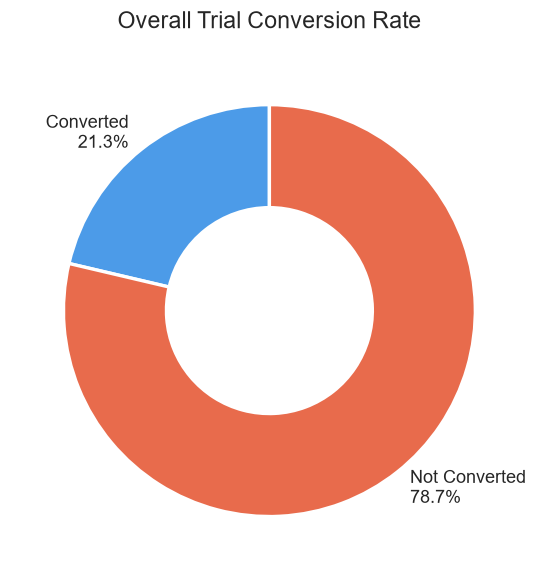

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))
sizes  = [n_converted, n_total - n_converted]
labels = [f'Converted\n{conv_rate:.1%}', f'Not Converted\n{1 - conv_rate:.1%}']
colors = ['#4C9BE8', '#E86B4C']
ax.pie(
    sizes, labels=labels, colors=colors, startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
)
ax.set_title('Overall Trial Conversion Rate', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

#### 6.2 Activity Usage: Converters vs Non-Converters

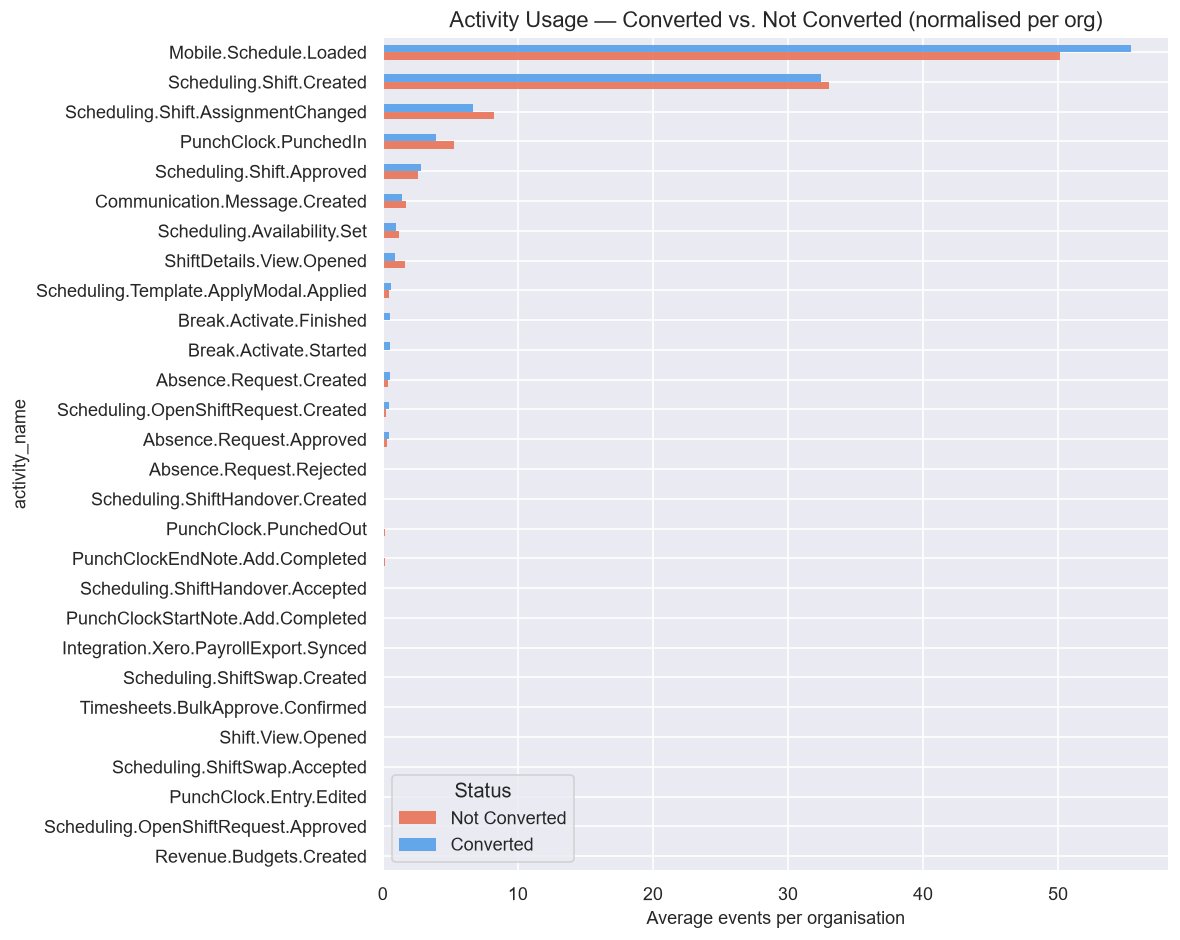

In [22]:
activity_conv = (
    df.groupby(['activity_name', 'converted'])
    .size()
    .rename('event_count')
    .reset_index()
)
activity_conv['events_per_org'] = activity_conv.apply(
    lambda r: r['event_count'] / conv_counts[r['converted']], axis=1
)
act_pivot = (
    activity_conv
    .pivot(index='activity_name', columns='converted', values='events_per_org')
    .fillna(0)
)
act_pivot.columns = ['Not Converted', 'Converted']
act_pivot = act_pivot.sort_values('Converted', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
act_pivot.plot(
    kind='barh', ax=ax,
    color=['#E86B4C', '#4C9BE8'], edgecolor='none', alpha=0.85
)
ax.set_xlabel('Average events per organisation')
ax.set_title('Activity Usage — Converted vs. Not Converted (normalised per org)')
ax.legend(title='Status')
plt.tight_layout()
plt.show()

#### 6.3 Daily Engagement Over the Trial Period

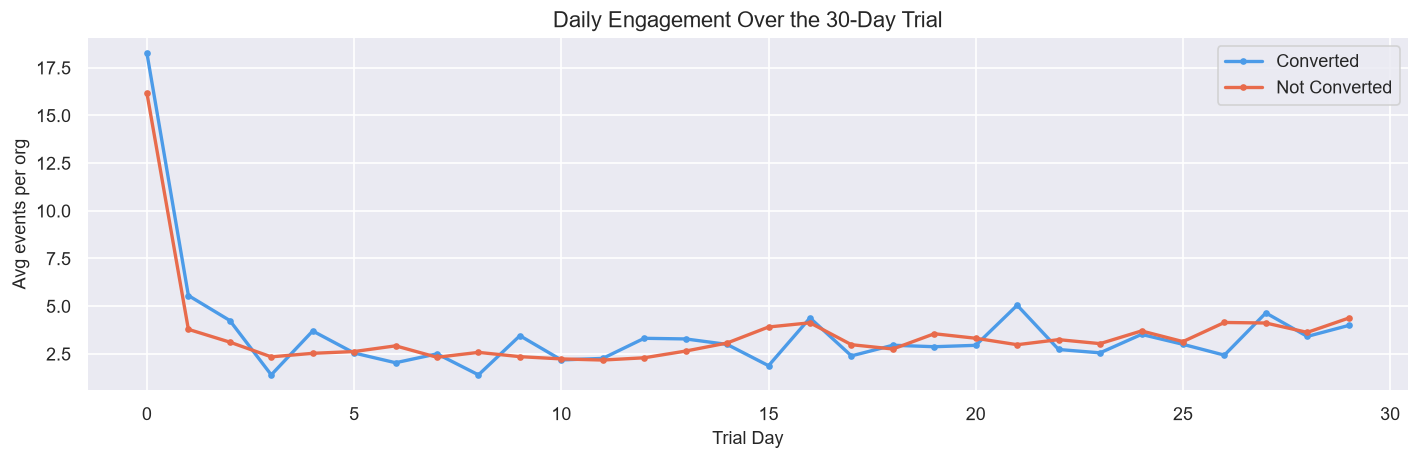

In [23]:
daily = (
    df.groupby(['trial_day', 'converted'])
    .size()
    .rename('events')
    .reset_index()
)
daily['events_per_org'] = daily.apply(
    lambda r: r['events'] / conv_counts[r['converted']], axis=1
)

fig, ax = plt.subplots(figsize=(12, 4))
for val, label, color in [
    (True,  'Converted',     '#4C9BE8'),
    (False, 'Not Converted', '#E86B4C'),
]:
    s = daily[daily['converted'] == val]
    ax.plot(
        s['trial_day'], s['events_per_org'],
        label=label, color=color, linewidth=2, marker='o', markersize=3
    )
ax.set_xlabel('Trial Day')
ax.set_ylabel('Avg events per org')
ax.set_title('Daily Engagement Over the 30-Day Trial')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
plt.tight_layout()
plt.show()

#### 6.4 Module Adoption Rate by Conversion Status

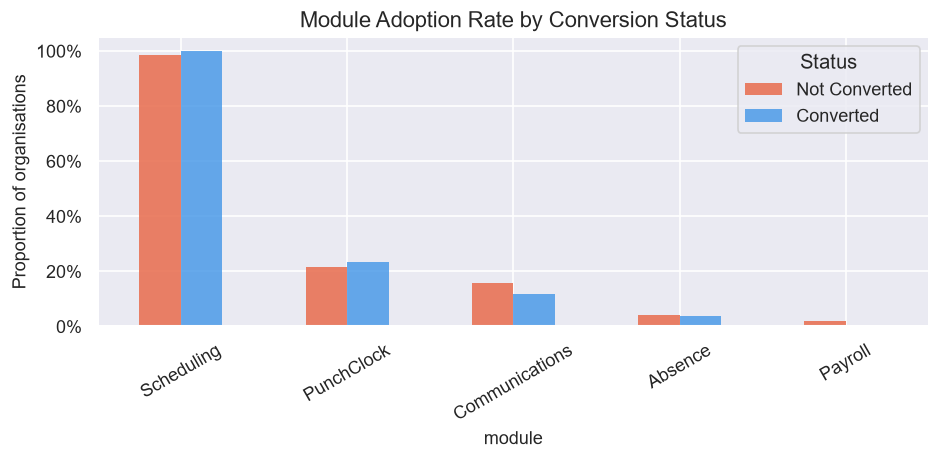

In [24]:
module_adoption = (
    df.groupby(['organization_id', 'module', 'converted'])
    .size()
    .reset_index(name='events')
    .groupby(['module', 'converted'])
    .agg(orgs_using=('organization_id', 'count'))
    .reset_index()
)
module_adoption['adoption_rate'] = module_adoption.apply(
    lambda r: r['orgs_using'] / conv_counts[r['converted']], axis=1
)
mod_pivot = (
    module_adoption
    .pivot(index='module', columns='converted', values='adoption_rate')
    .fillna(0)
)
mod_pivot.columns = ['Not Converted', 'Converted']
mod_pivot = mod_pivot.sort_values('Converted', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
mod_pivot.plot(
    kind='bar', ax=ax,
    color=['#E86B4C', '#4C9BE8'], edgecolor='none', alpha=0.85, rot=30
)
ax.set_ylabel('Proportion of organisations')
ax.set_title('Module Adoption Rate by Conversion Status')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title='Status')
plt.tight_layout()
plt.show()

#### 6.5 Event Volume Distribution per Org (log scale)

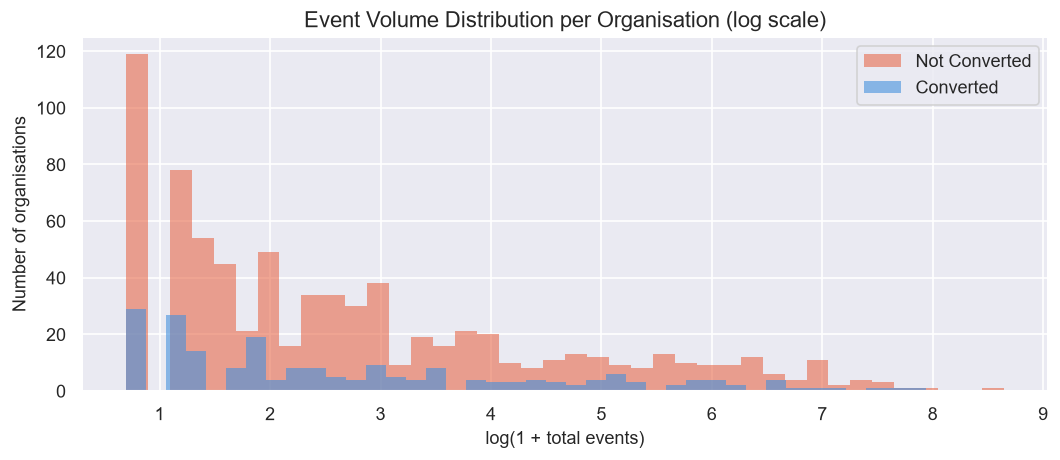

In [27]:
org_events = (
    df.groupby(['organization_id', 'converted'])
    .size()
    .reset_index(name='total_events')
)

fig, ax = plt.subplots(figsize=(9, 4))
for val, label, color in [
    (False, 'Not Converted', '#E86B4C'),
    (True,  'Converted',     "#4390DD"),
]:
    s = org_events[org_events['converted'] == val]['total_events']
    ax.hist(np.log1p(s), bins=40, alpha=0.6, label=label,
            color=color, edgecolor='none')
ax.set_xlabel('log(1 + total events)')
ax.set_ylabel('Number of organisations')
ax.set_title('Event Volume Distribution per Organisation (log scale)')
ax.legend()
plt.tight_layout()
plt.show()

#### 6.6 Time-to-Convert Distribution

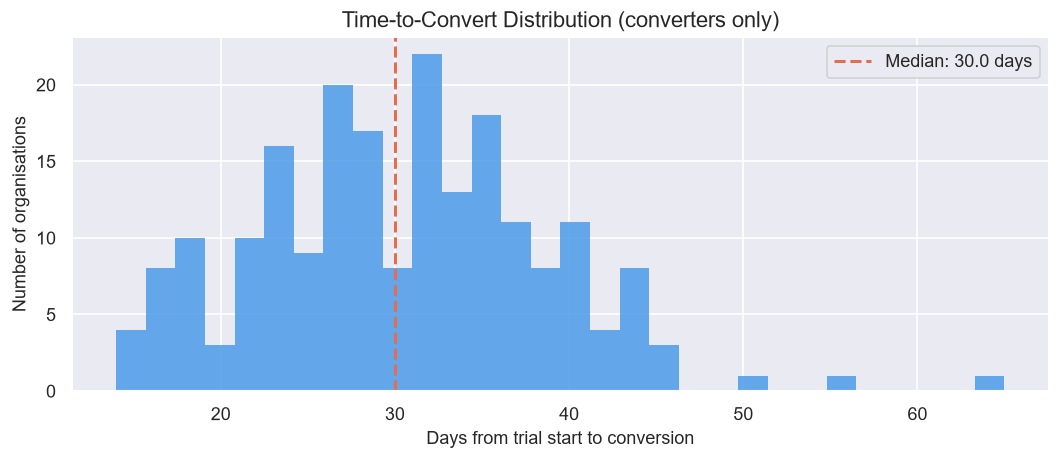

count   206.0000
mean     30.3555
std       8.2523
min      14.0015
25%      25.0024
50%      30.0163
75%      36.0010
max      64.9902
Name: days_to_convert, dtype: float64


In [28]:
converters = (
    df[df['converted']]
    .groupby('organization_id')
    .agg(days_to_convert=('days_to_convert', 'first'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    converters['days_to_convert'].dropna(), bins=30,
    color='#4C9BE8', edgecolor='none', alpha=0.85
)
median_val = converters['days_to_convert'].median()
ax.axvline(
    median_val, color='#E86B4C', linestyle='--', linewidth=1.8,
    label=f'Median: {median_val:.1f} days'
)
ax.set_xlabel('Days from trial start to conversion')
ax.set_ylabel('Number of organisations')
ax.set_title('Time-to-Convert Distribution (converters only)')
ax.legend()
plt.tight_layout()
plt.show()

print(converters['days_to_convert'].describe())

---
# 7. Save Cleaned Dataset

In [29]:
df.to_parquet('cleaned_events.parquet', index=False)
print('Saved → cleaned_events.parquet')
print(f'Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.dtypes

Saved → cleaned_events.parquet
Final shape: 102,895 rows x 10 columns


organization_id                 object
activity_name                   object
timestamp          datetime64[ns, UTC]
converted                         bool
converted_at       datetime64[ns, UTC]
trial_start        datetime64[ns, UTC]
trial_end          datetime64[ns, UTC]
trial_day                        int64
days_to_convert                float64
module                          object
dtype: object